<a href="https://colab.research.google.com/github/lilytong0919/NMA-shichimi-rulebreakerhalf-comparing-network/blob/main/Trajectory_plots_for_trials_grouped_by_animal_session.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
!{sys.executable} -m pip install -U pip --quiet
!{sys.executable} -m pip install motornet --quiet
!{sys.executable} -m pip install git+https://github.com/OlivierCodol/MotorNet.git --quiet

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
!pip install --no-cache-dir --force-reinstall --no-deps \
    git+https://github.com/lilytong0919/NMA-shichimi-rulebreakerhalf-comparing-network.git
!pip install pynapple --quiet

  Cloning https://github.com/lilytong0919/NMA-shichimi-rulebreakerhalf-comparing-network.git to /tmp/pip-req-build-2ijj1isb
  Running command git clone --filter=blob:none --quiet https://github.com/lilytong0919/NMA-shichimi-rulebreakerhalf-comparing-network.git /tmp/pip-req-build-2ijj1isb
  Resolved https://github.com/lilytong0919/NMA-shichimi-rulebreakerhalf-comparing-network.git to commit 975ae0b72037548bb7401d55de6a5eebcf3e8800
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for monkeypaw: filename=monkeypaw-0.1.0-py3-none-any.whl size=6158 sha256=d72ae430dbe9d7343674c1f392e48c49e692f6a54254034b6391a2db1bbe9e84
  Stored in directory: /tmp/pip-ephem-wheel-cache-kn0w75a_/wheels/c5/4d/e0/f4cdde16d1079b6e82b4e94fb243e7e447475b8f6c6ad15d9c
Successfully built monkeypaw
  Attempting uninstall: monkeypaw
    Found existing installation: monkeypaw 0.1.0
    Uninstalling monkeypaw-0.1.0:
   

In [3]:
!pip install dandi --quiet

In [4]:
!python3 -m pip install pynapple --quiet

In [5]:

from google.colab import drive
import monkeypaw.io as mpio
import pandas as pd
from dandi.download import download as dandi_download
import os
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt


# 2. Mount Google Drive for persistent storage
drive.mount('/content/drive')

# 3. Define a dedicated folder inside your Google Drive
drive_data_dir = "/content/drive/MyDrive/Dandi_Datasets/data"
os.makedirs(drive_data_dir, exist_ok=True)

filenames = [
    "sub-Dataset-3-Animals-1-to-4",
    "sub-Dataset-4-Animal-2-sess-1-to-7",
    "sub-Dataset-4-Animal-2-sess-8-to-12",
    "sub-Dataset-4-Animal-3-sess-1-to-6",
    "sub-Dataset-4-Animal-3-sess-7-to-11",
    "sub-Dataset-5-Animal-1",
    "sub-Dataset-5-Animals-2-ses-1-to-19",
    "sub-Dataset-5-Animals-2-ses-20-to-39",
    "sub-Dataset-5-Animals-2-ses-40-to-51",
    "sub-Dataset-5-Animals-3&4"
]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
url_base = 'https://dandiarchive.org/dandiset/001057/draft/files?location='

# 4. Check if the directory already has files to avoid starting the dandi client
if os.path.exists(drive_data_dir) and len(os.listdir(drive_data_dir)) >= len(filenames):
    print("✨ All files are already saved in Google Drive! Skipping download loop.")
else:
    print("⏳ Files missing. Running DANDI download loop straight to Google Drive...")
    for filename in filenames:
        url = url_base + filename
        # Downloads directly into your persistent Drive folder
        dandi_download(
            [url],
            output_dir=drive_data_dir,
            existing="skip"
        )
    print("✅ Download complete and saved to Google Drive.")


✨ All files are already saved in Google Drive! Skipping download loop.


**Shared keys between 3 dataset are also:** (different spelling)
- 'EventTarget_Onset' (dataset 3 and 4), 'EventTarget_onset'(dataset 5)
- 'target_dir'(dataset 3 and 4), 'targets_dir'(dataset 5)

Shared keys only between dataset 4 and 5:
- 'cursor_vel_y',  'cursor_vel_x', 'cursor_pos_y', 'cursor_pos_x',  'cursor_acc_y',  'cursor_acc_x'

**Also between dataset 4 and 5:** (different spelling)
- 'target_ID' (dataset 4), 'Target_ID'(dataset 5)

In [7]:
#dataset file id
id_file= 5
dat1 = mpio.nap_load_data(os.path.join(drive_data_dir,filenames[id_file],filenames[id_file]+'.nwb'))

Original keys: ['spikes_counts', 'trial_id', 'session', 'datasetID', 'animal', 'result', 'EventTarget_onset', 'EventGo_cue', 'targets_dir', 'cursor_vel_y', 'cursor_vel_x', 'cursor_pos_y', 'cursor_pos_x', 'cursor_acc_y', 'cursor_acc_x', 'Target_ID']
Renaming key 'EventTarget_onset' to 'EventTarget_Onset'
Renaming key 'targets_dir' to 'target_dir'
Renaming key 'Target_ID' to 'target_ID'


In [8]:
print(os.path.join(drive_data_dir,filenames[id_file],filenames[id_file]+'.nwb'))

/content/drive/MyDrive/Dandi_Datasets/data/sub-Dataset-5-Animal-1/sub-Dataset-5-Animal-1.nwb


In [9]:
dat1

sub-Dataset-5-Animal-1
┍━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━┑
│ Keys              │ Type     │
┝━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━┥
│ spikes_counts     │ TsdFrame │
│ trial_id          │ Tsd      │
│ session           │ Tsd      │
│ datasetID         │ Tsd      │
│ animal            │ Tsd      │
│ result            │ Tsd      │
│ EventGo_cue       │ Tsd      │
│ cursor_vel_y      │ Tsd      │
│ cursor_vel_x      │ Tsd      │
│ cursor_pos_y      │ Tsd      │
│ cursor_pos_x      │ Tsd      │
│ cursor_acc_y      │ Tsd      │
│ cursor_acc_x      │ Tsd      │
│ EventTarget_Onset │ Tsd      │
│ target_dir        │ Tsd      │
│ target_ID         │ Tsd      │
┕━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━┙

In [10]:
dat1_info = mpio.get_info(dat1)
dat1_info

Time (s)      trial_id    animal    datasetID    session    brain_region
----------  ----------  --------  -----------  ---------  --------------
0.0                  1         1            5          2             nan
0.01                 1         1            5          2             nan
0.02                 1         1            5          2             nan
0.03                 1         1            5          2             nan
0.04                 1         1            5          2             nan
0.05                 1         1            5          2             nan
0.06                 1         1            5          2             nan
...
42194.36           208         1            5         23             nan
42194.37           208         1            5         23             nan
42194.38           208         1            5         23             nan
42194.39           208         1            5         23             nan
42194.4            208         1            5  

In [11]:
dat1_behav = mpio.get_behav(dat1)
dat1_behav

Time (s)    EventGo_cue    EventTarget_Onset      target_ID    target_dir  result    ...
----------  -------------  -------------------  -----------  ------------  --------  -----
0.0         False          False                          6       3.14159  R         ...
0.01        False          False                          6       3.14159  R         ...
0.02        False          False                          6       3.14159  R         ...
0.03        False          False                          6       3.14159  R         ...
0.04        False          False                          6       3.14159  R         ...
0.05        False          False                          6       3.14159  R         ...
0.06        False          False                          6       3.14159  R         ...
...                                                                                  ...
42194.36    False          False                          5      -2.35619  R         ...
42194.37    False  

In [12]:
merged_dat1_df = pd.merge(dat1_info.as_dataframe(), dat1_behav.as_dataframe(), left_index=True, right_index=True, how='outer', suffixes=('_info', '_behav'))

display(merged_dat1_df.head())

,trial_id,animal,datasetID,session,brain_region,EventGo_cue,EventTarget_Onset,target_ID,target_dir,result,cursor_pos_x,cursor_pos_y,cursor_vel_x,cursor_vel_y,cursor_acc_x,cursor_acc_y
0.00,1,1,5,2,NaN,False,False,6.0,3.141593,R,1.101015,2.148711,1.172102,7.246896,-20.962863,-17.080041
0.01,1,1,5,2,NaN,False,False,6.0,3.141593,R,1.111634,2.220272,0.91951,7.002531,-27.792398,-30.416305
0.02,1,1,5,2,NaN,False,False,6.0,3.141593,R,1.119405,2.288762,0.616254,6.63857,-31.758559,-42.365646
0.03,1,1,5,2,NaN,False,False,6.0,3.141593,R,1.123959,2.353043,0.284339,6.155218,-33.293751,-53.85131
0.04,1,1,5,2,NaN,False,False,6.0,3.141593,R,1.125092,2.411866,-0.049621,5.561543,-31.617469,-62.227037


In [13]:
# adding time_s column
merged_dat1_df = merged_dat1_df.reset_index()
merged_dat1_df = merged_dat1_df.rename(columns={'index': 'time_s'})
display(merged_dat1_df)

,time_s,trial_id,animal,datasetID,session,brain_region,EventGo_cue,EventTarget_Onset,target_ID,target_dir,result,cursor_pos_x,cursor_pos_y,cursor_vel_x,cursor_vel_y,cursor_acc_x,cursor_acc_y
0,0.00,1,1,5,2,NaN,False,False,6.0,3.141593,R,1.101015,2.148711,1.172102,7.246896,-20.962863,-17.080041
1,0.01,1,1,5,2,NaN,False,False,6.0,3.141593,R,1.111634,2.220272,0.91951,7.002531,-27.792398,-30.416305
2,0.02,1,1,5,2,NaN,False,False,6.0,3.141593,R,1.119405,2.288762,0.616254,6.63857,-31.758559,-42.365646
3,0.03,1,1,5,2,NaN,False,False,6.0,3.141593,R,1.123959,2.353043,0.284339,6.155218,-33.293751,-53.85131
4,0.04,1,1,5,2,NaN,False,False,6.0,3.141593,R,1.125092,2.411866,-0.049621,5.561543,-31.617469,-62.227037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4219438,42194.38,208,1,5,23,NaN,False,False,5.0,-2.356194,R,-5.993402,-5.925285,-0.333889,0.236983,2.335312,-9.327658
4219439,42194.39,208,1,5,23,NaN,False,False,5.0,-2.356194,R,-5.99655,-5.923406,-0.279619,0.200054,5.467745,-0.858152
4219440,42194.40,208,1,5,23,NaN,False,False,5.0,-2.356194,R,-5.998995,-5.921284,-0.224534,0.21982,3.527271,0.02471
4219441,42194.41,208,1,5,23,NaN,False,False,5.0,-2.356194,R,-6.001041,-5.919009,-0.209074,0.200548,-0.984349,-2.643799


## Select animal

In [14]:
animal_selected = 1
# if column 'animal' is a string array
if type(merged_dat1_df['animal'][0]) == str:
  animal_selected = str(animal_selected)

anix_dat1_df = merged_dat1_df[merged_dat1_df['animal']==animal_selected]
anix_dat1_df

,time_s,trial_id,animal,datasetID,session,brain_region,EventGo_cue,EventTarget_Onset,target_ID,target_dir,result,cursor_pos_x,cursor_pos_y,cursor_vel_x,cursor_vel_y,cursor_acc_x,cursor_acc_y
0,0.00,1,1,5,2,NaN,False,False,6.0,3.141593,R,1.101015,2.148711,1.172102,7.246896,-20.962863,-17.080041
1,0.01,1,1,5,2,NaN,False,False,6.0,3.141593,R,1.111634,2.220272,0.91951,7.002531,-27.792398,-30.416305
2,0.02,1,1,5,2,NaN,False,False,6.0,3.141593,R,1.119405,2.288762,0.616254,6.63857,-31.758559,-42.365646
3,0.03,1,1,5,2,NaN,False,False,6.0,3.141593,R,1.123959,2.353043,0.284339,6.155218,-33.293751,-53.85131
4,0.04,1,1,5,2,NaN,False,False,6.0,3.141593,R,1.125092,2.411866,-0.049621,5.561543,-31.617469,-62.227037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4219438,42194.38,208,1,5,23,NaN,False,False,5.0,-2.356194,R,-5.993402,-5.925285,-0.333889,0.236983,2.335312,-9.327658
4219439,42194.39,208,1,5,23,NaN,False,False,5.0,-2.356194,R,-5.99655,-5.923406,-0.279619,0.200054,5.467745,-0.858152
4219440,42194.40,208,1,5,23,NaN,False,False,5.0,-2.356194,R,-5.998995,-5.921284,-0.224534,0.21982,3.527271,0.02471
4219441,42194.41,208,1,5,23,NaN,False,False,5.0,-2.356194,R,-6.001041,-5.919009,-0.209074,0.200548,-0.984349,-2.643799


### Plotting Cursor Trajectory Function

Here's a function `plot_cursor_trajectory` that sums up the logic for calculating target direction and plotting the cursor trajectory, along with event markers and proper axis scaling. It takes `df_gpb_session_trial` as its only argument.

In [34]:
def plot_cursor_trajectory(df_gpb_session_trial):

    if df_gpb_session_trial.empty:
        print("DataFrame is empty, cannot plot trajectory.")
        return

    # Calculate unique target directions
    unique_target_dirs_rad = df_gpb_session_trial['target_dir'].unique()
    unique_target_dirs_deg = [np.degrees(direction) for direction in unique_target_dirs_rad]

    # Format target direction for title and labels, handling NaN
    target_dir_title = "N/A"
    if unique_target_dirs_deg and not pd.isna(unique_target_dirs_deg[0]):
        target_dir_title = f"{int(unique_target_dirs_deg[0])}°"

    # Print statement for target direction (original code had this before the if/else for cursor_pos_x.isnull().all())
    if unique_target_dirs_deg:
        print('Target direction for session ',df_gpb_session_trial['session'].unique()[0],', trial ', df_gpb_session_trial['trial_id'].unique()[0],': ', unique_target_dirs_deg[0], ' degrees')


    # Check if cursor position data is all NaN
    if df_gpb_session_trial['cursor_pos_x'].isnull().all() or df_gpb_session_trial['cursor_pos_y'].isnull().all():
        print(f"Warning: No valid cursor position data (cursor_pos_x or cursor_pos_y are all NaN) for Animal {df_gpb_session_trial['animal'].iloc[0]}, Session {df_gpb_session_trial['session'].iloc[0]}, Trial {df_gpb_session_trial['trial_id'].iloc[0]}. Plotting axes with default limits.")

        plt.figure(figsize=(8, 8))
        plt.axhline(0, color='black', linewidth=1.5, linestyle='-', zorder=0)
        plt.axvline(0, color='black', linewidth=1.5, linestyle='-', zorder=0)

        # default limits when no cursor data
        default_limit = 10.0 # default for cursor positions
        plt.xlim(-default_limit, default_limit)
        plt.ylim(-default_limit, default_limit)

        plt.xlabel('Cursor Position X (cm)')
        plt.ylabel('Cursor Position Y (cm)')

        result_dic = {'R':'Rewarded','A':'Aborted','F':'Failed','I':'Incomplete'}
        # Ensure 'result' exists and is not empty
        if not df_gpb_session_trial['result'].empty:
            result_str = result_dic.get(df_gpb_session_trial['result'].iloc[0], 'Unknown')
        else:
            result_str = 'N/A'

        # line for target direction
        if unique_target_dirs_deg and not pd.isna(unique_target_dirs_deg[0]):
            target_angle_rad = np.radians(unique_target_dirs_deg[0])
            line_length = 15
            target_line_x = [0, line_length * np.cos(target_angle_rad)]
            target_line_y = [0, line_length * np.sin(target_angle_rad)]
            plt.plot(target_line_x, target_line_y, linestyle='--', color='yellow', linewidth=2, zorder=1, label=f'Target Direction ({target_dir_title})')

        plt.title(f"Cursor Trajectory for Dataset {df_gpb_session_trial['datasetID'].iloc[0]}: Animal {df_gpb_session_trial['animal'].iloc[0]}, Session {df_gpb_session_trial['session'].iloc[0]}, Trial {df_gpb_session_trial['trial_id'].iloc[0]} - Target {target_dir_title}, result {result_str}")
        plt.grid(True)
        plt.gca().set_aspect('equal', adjustable='box')
        plt.show()
        return


    # Get trial start time
    trial_start_time = df_gpb_session_trial['time_s'].iloc[0]

    # Draw darker axis lines at 0,0
    plt.figure(figsize=(8, 8))
    plt.axhline(0, color='black', linewidth=1.5, linestyle='-', zorder=0)
    plt.axvline(0, color='black', linewidth=1.5, linestyle='-', zorder=0)

    plt.plot(df_gpb_session_trial['cursor_pos_x'], df_gpb_session_trial['cursor_pos_y'], marker='.', linestyle='-', label='Cursor Trajectory')
    plt.plot(df_gpb_session_trial['cursor_pos_x'].iloc[0], df_gpb_session_trial['cursor_pos_y'].iloc[0], marker='*', color='red', markersize=15, label='Start Point')

    # Mark EventTarget_Onset points
    target_onset_rows = df_gpb_session_trial[df_gpb_session_trial['EventTarget_Onset'] == True]
    target_onset_x = target_onset_rows['cursor_pos_x']
    target_onset_y = target_onset_rows['cursor_pos_y']
    if not target_onset_rows.empty:
        relative_target_onset_time = target_onset_rows['time_s'].iloc[0] - trial_start_time
        plt.plot(target_onset_x, target_onset_y, 'o', color='green', markersize=10, label=f'Target Onset ({relative_target_onset_time:.2f} s)')
    else:
        plt.plot([], [], 'o', color='green', markersize=10, label='Target Onset (N/A)') # Plot empty if no events

    # Mark EventGo_cue points
    go_cue_rows = df_gpb_session_trial[df_gpb_session_trial['EventGo_cue'] == True]
    go_cue_x = go_cue_rows['cursor_pos_x']
    go_cue_y = go_cue_rows['cursor_pos_y']
    if not go_cue_rows.empty:
        relative_go_cue_time = go_cue_rows['time_s'].iloc[0] - trial_start_time
        plt.plot(go_cue_x, go_cue_y, 'x', color='purple', markersize=10, label=f'Go Cue ({relative_go_cue_time:.2f} s)')
    else:
        plt.plot([], [], 'x', color='purple', markersize=10, label='Go Cue (N/A)') # Plot empty if no events

    # Mark the endpoint
    endpoint_row = df_gpb_session_trial.iloc[-1]
    endpoint_x = endpoint_row['cursor_pos_x']
    endpoint_y = endpoint_row['cursor_pos_y']
    relative_endpoint_time = endpoint_row['time_s'] - trial_start_time
    plt.plot(endpoint_x, endpoint_y, 's', color='blue', markersize=10, label=f'Endpoint ({relative_endpoint_time:.2f} s)')

    # Calculate symmetric ranges for x and y axes centered at 0
    x_min_data = df_gpb_session_trial['cursor_pos_x'].min()
    x_max_data = df_gpb_session_trial['cursor_pos_x'].max()
    y_min_data = df_gpb_session_trial['cursor_pos_y'].min()
    y_max_data = df_gpb_session_trial['cursor_pos_y'].max()

    # Determine the maximum absolute value among all min/max data points
    max_abs_val = max(abs(x_min_data), abs(x_max_data), abs(y_min_data), abs(y_max_data))+0.5

    # Set new symmetric limits based on the maximum absolute value, centered at 0
    plt.xlim(-max_abs_val, max_abs_val)
    plt.ylim(-max_abs_val, max_abs_val)

    # Add line for target direction
    if unique_target_dirs_deg and not pd.isna(unique_target_dirs_deg[0]):
        target_angle_rad = np.radians(unique_target_dirs_deg[0])
        line_length = max_abs_val * 1.5
        target_line_x = [0, line_length * np.cos(target_angle_rad)]
        target_line_y = [0, line_length * np.sin(target_angle_rad)]
        plt.plot(target_line_x, target_line_y, linestyle='--', color='yellow', linewidth=2, zorder=1, label=f'Target Direction ({target_dir_title})')
    else:
        plt.plot([], [], linestyle='--', color='yellow', linewidth=2, zorder=1, label='Target Direction (N/A)')


    result_dic = {'R':'Rewarded','A':'Aborted','F':'Failed','I':'Incomplete'}
    result_str = result_dic[df_gpb_session_trial['result'].iloc[0]]

    plt.xlabel('Cursor Position X (cm)')
    plt.ylabel('Cursor Position Y (cm)')
    plt.title(f"Cursor Trajectory for Dataset {df_gpb_session_trial['datasetID'].iloc[0]}: Animal {df_gpb_session_trial['animal'].iloc[0]}, Session {df_gpb_session_trial['session'].iloc[0]}, Trial {df_gpb_session_trial['trial_id'].iloc[0]} - Target {target_dir_title}, result {result_str}")
    plt.grid(True)
    plt.gca().set_aspect('equal', adjustable='box') # Equal scaling for x and y axes
    plt.legend()
    plt.show()

### Selecting session and trial for animal x

In [56]:
session_selected = 10
trial_selected = 25
if type(merged_dat1_df['session'][0]) == str:
  session_selected = str(session_selected)

if type(merged_dat1_df['trial_id'][0]) == str:
  trial_selected = str(trial_selected)

df_gpb_session_trial = anix_dat1_df[(anix_dat1_df['session'] == session_selected) & (anix_dat1_df['trial_id'] == trial_selected)]
df_gpb_session_trial


,time_s,trial_id,animal,datasetID,session,brain_region,EventGo_cue,EventTarget_Onset,target_ID,target_dir,result,cursor_pos_x,cursor_pos_y,cursor_vel_x,cursor_vel_y,cursor_acc_x,cursor_acc_y
1265833,12658.33,25,1,5,10,NaN,False,False,7.0,2.356194,R,-0.234093,7.741314,0.13038,0.031164,-4.590109,27.863023
1265834,12658.34,25,1,5,10,NaN,False,False,7.0,2.356194,R,-0.233065,7.743425,0.10316,0.30257,-1.840159,16.121124
1265835,12658.35,25,1,5,10,NaN,False,False,7.0,2.356194,R,-0.23203,7.747365,0.093577,0.353586,-1.843465,-6.359921
1265836,12658.36,25,1,5,10,NaN,False,False,7.0,2.356194,R,-0.231194,7.750497,0.066291,0.175372,-2.24736,-25.519201
1265837,12658.37,25,1,5,10,NaN,False,False,7.0,2.356194,R,-0.230704,7.750873,0.04863,-0.156798,-0.511846,-33.062974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1266250,12662.50,25,1,5,10,NaN,False,False,7.0,2.356194,R,-4.988298,5.391524,0.16182,-0.220173,-0.203682,-3.24287
1266251,12662.51,25,1,5,10,NaN,False,False,7.0,2.356194,R,-4.986712,5.389185,0.172737,-0.321755,3.451301,-11.139954
1266252,12662.52,25,1,5,10,NaN,False,False,7.0,2.356194,R,-4.984844,5.385089,0.230846,-0.442972,8.96957,-3.734716
1266253,12662.53,25,1,5,10,NaN,False,False,7.0,2.356194,R,-4.982095,5.380325,0.352129,-0.39645,12.666143,9.98485


Now we call the function `plot_cursor_trajectory` to generate the plot:

Target direction for session  10 , trial  25 :  135.0  degrees


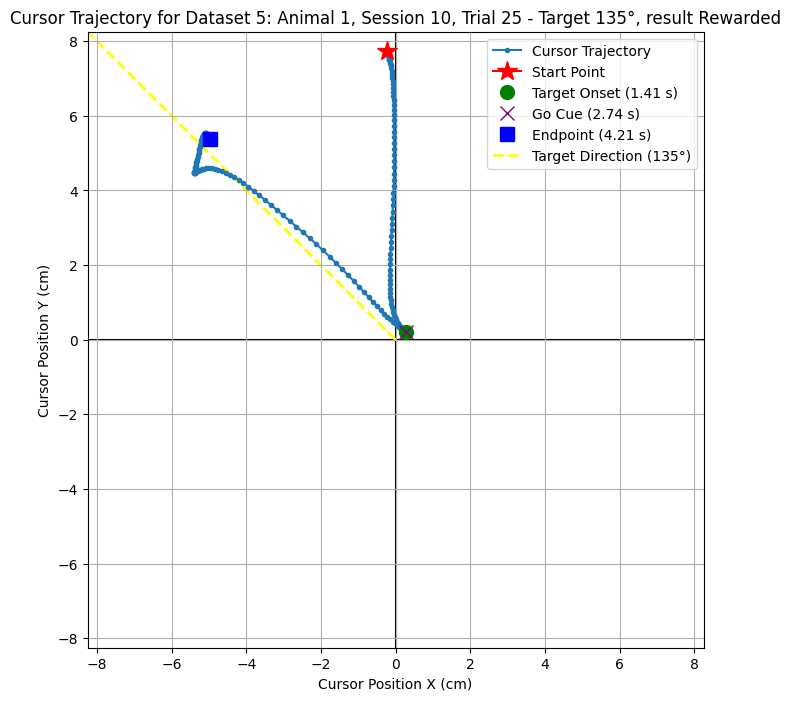

In [57]:
plot_cursor_trajectory(df_gpb_session_trial)

In [58]:

session_selected = 2
trial_selected = 2

if type(merged_dat1_df['session'][0]) == str:
  session_selected = str(session_selected)

if type(merged_dat1_df['trial_id'][0]) == str:
  trial_selected = str(trial_selected)

df_gpb_session_trial = anix_dat1_df[(anix_dat1_df['session'] == session_selected) & (anix_dat1_df['trial_id'] == trial_selected)]
df_gpb_session_trial

,time_s,trial_id,animal,datasetID,session,brain_region,EventGo_cue,EventTarget_Onset,target_ID,target_dir,result,cursor_pos_x,cursor_pos_y,cursor_vel_x,cursor_vel_y,cursor_acc_x,cursor_acc_y
398,3.98,2,1,5,2,NaN,False,False,2.0,0.0,A,-6.943956,-0.301244,1.710586,-1.154413,25.767519,6.645259
399,3.99,2,1,5,2,NaN,False,False,2.0,0.0,A,-6.925613,-0.312529,1.980109,-1.08856,29.437754,8.243248
400,4.00,2,1,5,2,NaN,False,False,2.0,0.0,A,-6.904354,-0.323015,2.299342,-0.989549,33.4089,10.709727
401,4.01,2,1,5,2,NaN,False,False,2.0,0.0,A,-6.879626,-0.33232,2.648287,-0.874365,34.357304,10.859391
402,4.02,2,1,5,2,NaN,False,False,2.0,0.0,A,-6.851388,-0.340503,2.986488,-0.772361,33.114954,9.531894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549,5.49,2,1,5,2,NaN,False,False,2.0,0.0,A,0.720117,0.763497,2.931326,5.160751,8.92879,6.267937
550,5.50,2,1,5,2,NaN,False,False,2.0,0.0,A,0.749833,0.815451,3.047983,5.13359,11.343494,-8.606425
551,5.51,2,1,5,2,NaN,False,False,2.0,0.0,A,0.781076,0.866168,3.158196,4.988622,5.536745,-14.661876
552,5.52,2,1,5,2,NaN,False,False,2.0,0.0,A,0.812997,0.915223,3.158717,4.840352,-1.761213,-15.753376


Target direction for session  2 , trial  2 :  0.0  degrees


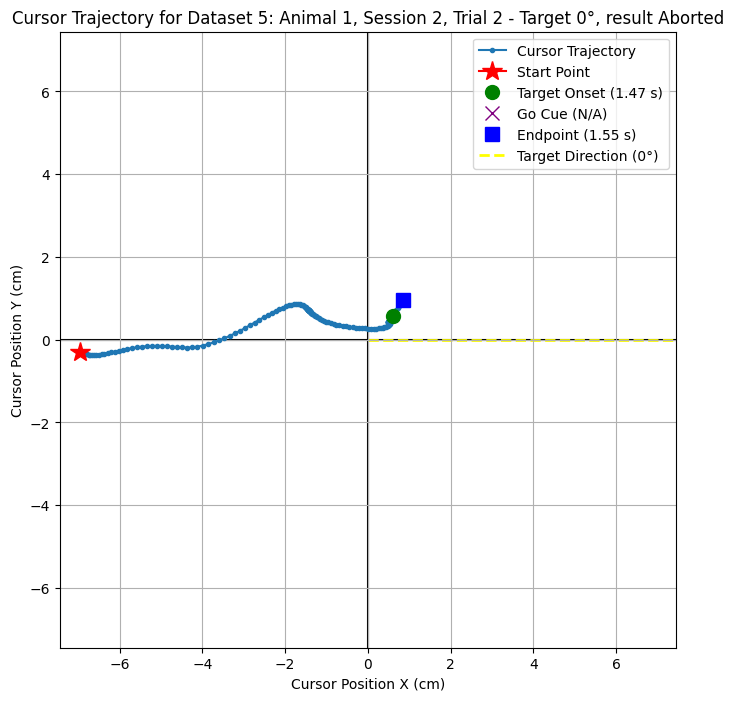

In [59]:
plot_cursor_trajectory(df_gpb_session_trial)

In [60]:
session_selected = 2
trial_selected = 3

if type(merged_dat1_df['session'][0]) == str:
  session_selected = str(session_selected)

if type(merged_dat1_df['trial_id'][0]) == str:
  trial_selected = str(trial_selected)

df_gpb_session_trial = anix_dat1_df[(anix_dat1_df['session'] == session_selected) & (anix_dat1_df['trial_id'] == trial_selected)]
df_gpb_session_trial

,time_s,trial_id,animal,datasetID,session,brain_region,EventGo_cue,EventTarget_Onset,target_ID,target_dir,result,cursor_pos_x,cursor_pos_y,cursor_vel_x,cursor_vel_y,cursor_acc_x,cursor_acc_y
554,5.54,3,1,5,2,NaN,False,False,0.0,1.570796,I,1.625572,1.482839,7.102205,-0.409965,45.956753,-15.09939
555,5.55,3,1,5,2,NaN,False,False,0.0,1.570796,I,1.698859,1.478009,7.547276,-0.559762,43.05411,-14.564551
556,5.56,3,1,5,2,NaN,False,False,0.0,1.570796,I,1.776518,1.471644,7.963287,-0.701256,38.850436,-11.472278
557,5.57,3,1,5,2,NaN,False,False,0.0,1.570796,I,1.858125,1.463984,8.324285,-0.789207,32.207922,-4.396578
558,5.58,3,1,5,2,NaN,False,False,0.0,1.570796,I,1.943004,1.45586,8.607445,-0.789188,23.863988,2.466492
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1107,11.07,3,1,5,2,NaN,False,False,0.0,1.570796,I,-0.295735,8.301678,-4.324933,20.319723,-5.029268,-203.187356
1108,11.08,3,1,5,2,NaN,False,False,0.0,1.570796,I,-0.339306,8.494759,-4.365209,18.172109,-0.712725,-225.82992
1109,11.09,3,1,5,2,NaN,False,False,0.0,1.570796,I,-0.383039,8.66512,-4.339188,15.803125,5.636295,-241.532727
1110,11.10,3,1,5,2,NaN,False,False,0.0,1.570796,I,-0.42609,8.810821,-4.252483,13.341454,9.523691,-241.073136


Target direction for session  2 , trial  3 :  90.0  degrees


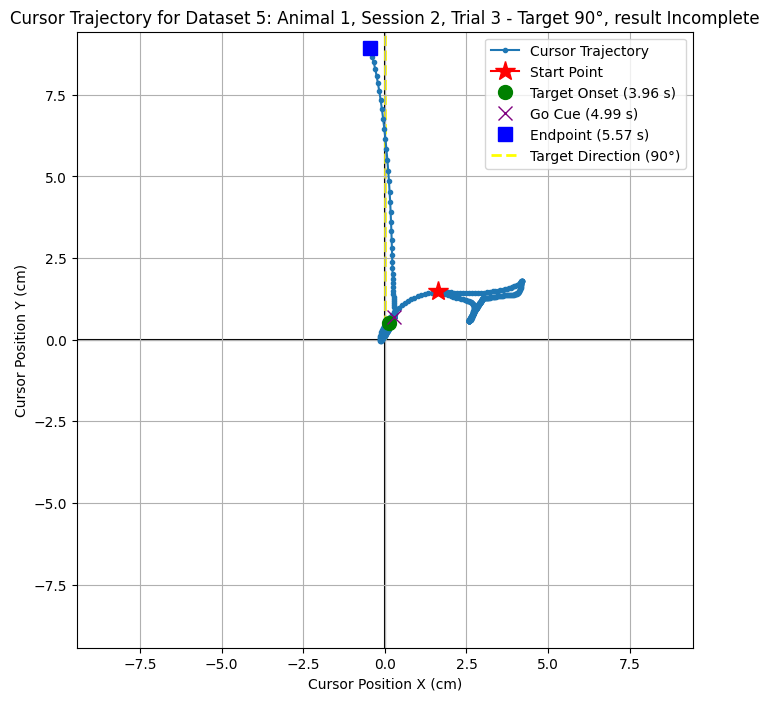

In [61]:
plot_cursor_trajectory(df_gpb_session_trial)

In [62]:
session_selected = 2
trial_selected = 4

if type(merged_dat1_df['session'][0]) == str:
  session_selected = str(session_selected)

if type(merged_dat1_df['trial_id'][0]) == str:
  trial_selected = str(trial_selected)

df_gpb_session_trial = anix_dat1_df[(anix_dat1_df['session'] == session_selected) & (anix_dat1_df['trial_id'] == trial_selected)]
df_gpb_session_trial

,time_s,trial_id,animal,datasetID,session,brain_region,EventGo_cue,EventTarget_Onset,target_ID,target_dir,result,cursor_pos_x,cursor_pos_y,cursor_vel_x,cursor_vel_y,cursor_acc_x,cursor_acc_y
1112,11.12,4,1,5,2,NaN,False,False,4.0,-1.570796,F,-0.669234,8.550672,0.878202,0.388732,-9.988144,25.694187
1113,11.13,4,1,5,2,NaN,False,False,4.0,-1.570796,F,-0.660822,8.555836,0.75157,0.608055,-16.559743,18.434159
1114,11.14,4,1,5,2,NaN,False,False,4.0,-1.570796,F,-0.654203,8.562833,0.547007,0.757415,-19.313163,10.523423
1115,11.15,4,1,5,2,NaN,False,False,4.0,-1.570796,F,-0.649882,8.570985,0.365307,0.818523,-12.857139,0.826294
1116,11.16,4,1,5,2,NaN,False,False,4.0,-1.570796,F,-0.646896,8.579203,0.289864,0.773941,-4.196401,-7.30434
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1636,16.36,4,1,5,2,NaN,False,False,4.0,-1.570796,F,0.772548,-0.560987,0.477409,-0.26701,-12.878188,-16.878497
1637,16.37,4,1,5,2,NaN,False,False,4.0,-1.570796,F,0.77636,-0.565089,0.397747,-0.369242,0.647688,4.957033
1638,16.38,4,1,5,2,NaN,False,False,4.0,-1.570796,F,0.780503,-0.568372,0.490363,-0.16787,9.02563,20.113106
1639,16.39,4,1,5,2,NaN,False,False,4.0,-1.570796,F,0.786167,-0.568447,0.578259,0.03302,1.605451,6.310886


Target direction for session  2 , trial  4 :  -90.0  degrees


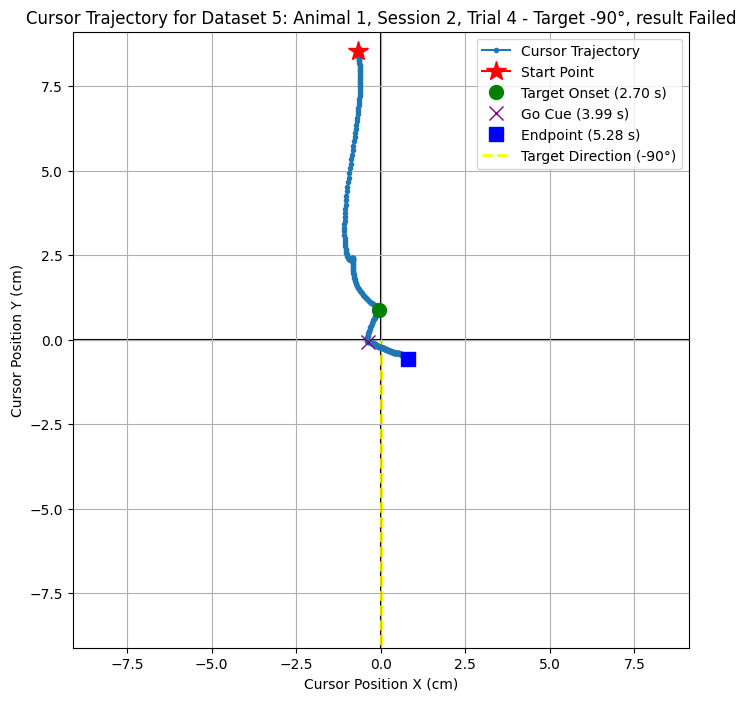

In [63]:
plot_cursor_trajectory(df_gpb_session_trial)

In [64]:
session_selected = 2
trial_selected = 5

if type(merged_dat1_df['session'][0]) == str:
  session_selected = str(session_selected)

if type(merged_dat1_df['trial_id'][0]) == str:
  trial_selected = str(trial_selected)

df_gpb_session_trial = anix_dat1_df[(anix_dat1_df['session'] == session_selected) & (anix_dat1_df['trial_id'] == trial_selected)]
df_gpb_session_trial

,time_s,trial_id,animal,datasetID,session,brain_region,EventGo_cue,EventTarget_Onset,target_ID,target_dir,result,cursor_pos_x,cursor_pos_y,cursor_vel_x,cursor_vel_y,cursor_acc_x,cursor_acc_y
1641,16.41,5,1,5,2,NaN,False,False,NaN,NaN,A,0.8218,-0.590271,0.008358,-0.019828,-8.001414,7.40133
1642,16.42,5,1,5,2,NaN,False,False,NaN,NaN,A,0.821535,-0.590136,-0.020495,0.030145,-1.727887,3.324655
1643,16.43,5,1,5,2,NaN,False,False,NaN,NaN,A,0.82139,-0.589668,-0.026199,0.046665,0.55849,-2.508921
1644,16.44,5,1,5,2,NaN,False,False,NaN,NaN,A,0.821011,-0.589203,-0.009325,-0.020034,8.13616,-10.554389
1645,16.45,5,1,5,2,NaN,False,False,NaN,NaN,A,0.821203,-0.590068,0.136524,-0.164422,17.389358,-8.382719
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1698,16.98,5,1,5,2,NaN,False,False,NaN,NaN,A,0.99142,-0.592078,0.235919,0.270199,1.475678,3.120532
1699,16.99,5,1,5,2,NaN,False,False,NaN,NaN,A,0.993931,-0.589175,0.1579,0.225734,-12.128395,-9.287009
1700,17.00,5,1,5,2,NaN,False,False,NaN,NaN,A,0.994578,-0.587563,-0.006649,0.084459,-8.497956,-13.84299
1701,17.01,5,1,5,2,NaN,False,False,NaN,NaN,A,0.993798,-0.587486,-0.012059,-0.051126,9.112328,-12.166705


Target direction for session  2 , trial  5 :  nan  degrees


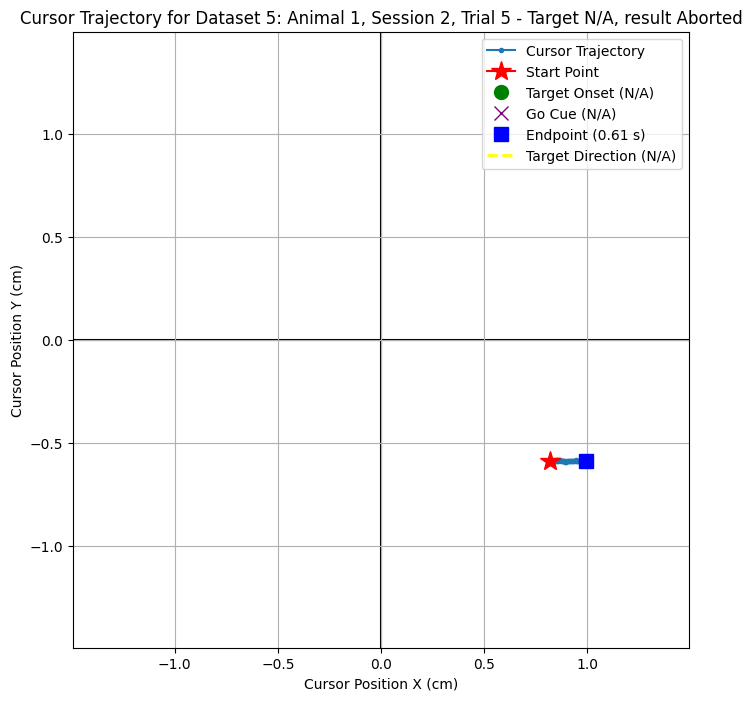

In [65]:
plot_cursor_trajectory(df_gpb_session_trial)

In [66]:
session_selected = 2
trial_selected = 10

if type(merged_dat1_df['session'][0]) == str:
  session_selected = str(session_selected)

if type(merged_dat1_df['trial_id'][0]) == str:
  trial_selected = str(trial_selected)

df_gpb_session_trial = anix_dat1_df[(anix_dat1_df['session'] == session_selected) & (anix_dat1_df['trial_id'] == trial_selected)]
df_gpb_session_trial

,time_s,trial_id,animal,datasetID,session,brain_region,EventGo_cue,EventTarget_Onset,target_ID,target_dir,result,cursor_pos_x,cursor_pos_y,cursor_vel_x,cursor_vel_y,cursor_acc_x,cursor_acc_y
2016,20.16,10,1,5,2,NaN,False,False,3.0,-0.785398,R,-0.05215,1.454529,-0.217664,-0.322109,4.882503,13.093215
2017,20.17,10,1,5,2,NaN,False,False,3.0,-0.785398,R,-0.05421,1.452012,-0.153712,-0.142835,11.094365,14.936558
2018,20.18,10,1,5,2,NaN,False,False,3.0,-0.785398,R,-0.055225,1.451672,0.004224,-0.023378,17.299132,1.229892
2019,20.19,10,1,5,2,NaN,False,False,3.0,-0.785398,R,-0.054125,1.451544,0.19227,-0.118237,12.8094,-12.54946
2020,20.20,10,1,5,2,NaN,False,False,3.0,-0.785398,R,-0.051379,1.449307,0.260412,-0.274367,-0.352867,-4.634787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2427,24.27,10,1,5,2,NaN,False,False,3.0,-0.785398,R,6.134571,-5.428404,-0.315756,0.081745,-20.261929,-10.958656
2428,24.28,10,1,5,2,NaN,False,False,3.0,-0.785398,R,6.130364,-5.428135,-0.354426,-0.085464,2.358523,-15.817334
2429,24.29,10,1,5,2,NaN,False,False,3.0,-0.785398,R,6.127483,-5.430113,-0.268586,-0.234601,0.040831,-6.499441
2430,24.30,10,1,5,2,NaN,False,False,3.0,-0.785398,R,6.124993,-5.432827,-0.353609,-0.215453,-14.664617,4.941286


Target direction for session  2 , trial  10 :  -45.0  degrees


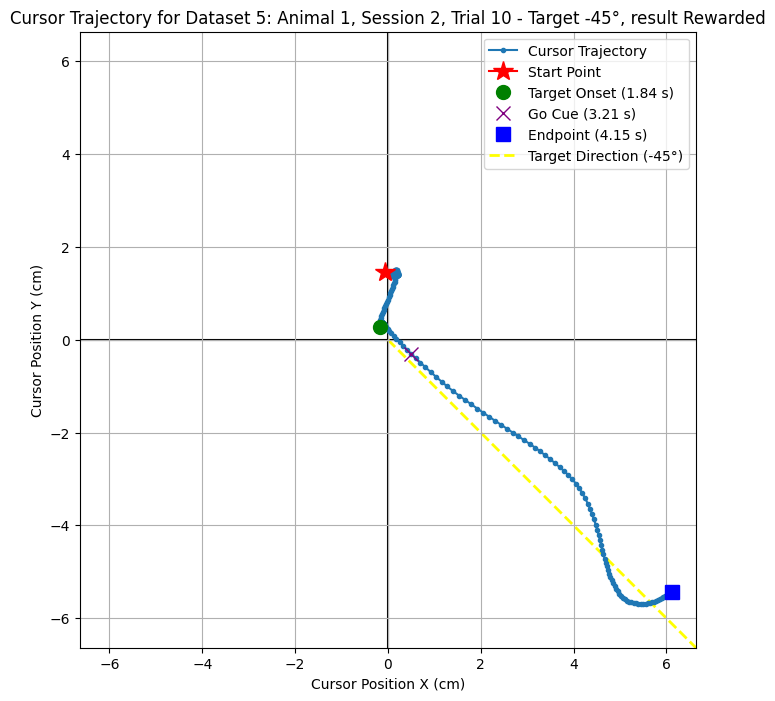

In [67]:
plot_cursor_trajectory(df_gpb_session_trial)

In [68]:
session_selected = 2
trial_selected = 12

if type(merged_dat1_df['session'][0]) == str:
  session_selected = str(session_selected)

if type(merged_dat1_df['trial_id'][0]) == str:
  trial_selected = str(trial_selected)

df_gpb_session_trial = anix_dat1_df[(anix_dat1_df['session'] == session_selected) & (anix_dat1_df['trial_id'] == trial_selected)]
df_gpb_session_trial

,time_s,trial_id,animal,datasetID,session,brain_region,EventGo_cue,EventTarget_Onset,target_ID,target_dir,result,cursor_pos_x,cursor_pos_y,cursor_vel_x,cursor_vel_y,cursor_acc_x,cursor_acc_y
2702,27.02,12,1,5,2,NaN,False,False,2.0,0.0,R,-1.317578,0.998927,-2.630125,3.959168,-35.670348,70.492989
2703,27.03,12,1,5,2,NaN,False,False,2.0,0.0,R,-1.345617,1.04207,-2.998994,4.692278,-39.473985,74.46935
2704,27.04,12,1,5,2,NaN,False,False,2.0,0.0,R,-1.377558,1.092773,-3.419605,5.448555,-44.60934,75.887971
2705,27.05,12,1,5,2,NaN,False,False,2.0,0.0,R,-1.414009,1.151041,-3.891181,6.210038,-49.525902,77.022607
2706,27.06,12,1,5,2,NaN,False,False,2.0,0.0,R,-1.455382,1.216974,-4.410123,6.989008,-54.845594,77.757554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3070,30.70,12,1,5,2,NaN,False,False,2.0,0.0,R,8.10332,0.368773,0.387241,-0.191938,5.179043,-0.748272
3071,30.71,12,1,5,2,NaN,False,False,2.0,0.0,R,8.107379,0.36693,0.402049,-0.17403,2.100372,0.22376
3072,30.72,12,1,5,2,NaN,False,False,2.0,0.0,R,8.111361,0.365292,0.429249,-0.187463,4.532836,-3.211707
3073,30.73,12,1,5,2,NaN,False,False,2.0,0.0,R,8.115964,0.363181,0.492706,-0.238265,2.557966,-2.556426


Target direction for session  2 , trial  12 :  0.0  degrees


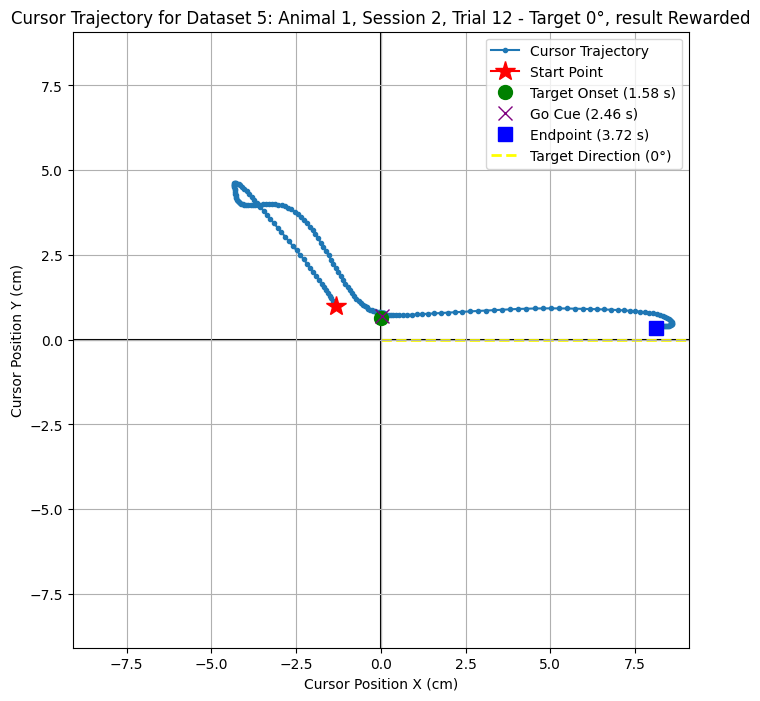

In [69]:
plot_cursor_trajectory(df_gpb_session_trial)

In [70]:
session_selected = 2
trial_selected = 15

if type(merged_dat1_df['session'][0]) == str:
  session_selected = str(session_selected)

if type(merged_dat1_df['trial_id'][0]) == str:
  trial_selected = str(trial_selected)

df_gpb_session_trial = anix_dat1_df[(anix_dat1_df['session'] == session_selected) & (anix_dat1_df['trial_id'] == trial_selected)]
df_gpb_session_trial

,time_s,trial_id,animal,datasetID,session,brain_region,EventGo_cue,EventTarget_Onset,target_ID,target_dir,result,cursor_pos_x,cursor_pos_y,cursor_vel_x,cursor_vel_y,cursor_acc_x,cursor_acc_y
3575,35.75,15,1,5,2,NaN,False,False,7.0,2.356194,R,0.995406,-1.165441,0.161731,-0.119989,12.425677,-10.205805
3576,35.76,15,1,5,2,NaN,False,False,7.0,2.356194,R,0.998055,-1.1675,0.289003,-0.224361,2.873488,-2.375989
3577,35.77,15,1,5,2,NaN,False,False,7.0,2.356194,R,1.001186,-1.169928,0.219201,-0.167509,-12.067985,9.562276
3578,35.78,15,1,5,2,NaN,False,False,7.0,2.356194,R,1.002439,-1.17085,0.047644,-0.033116,-12.447066,9.549933
3579,35.79,15,1,5,2,NaN,False,False,7.0,2.356194,R,1.002139,-1.17059,-0.02974,0.02349,-3.514421,2.434839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4511,45.11,15,1,5,2,NaN,False,False,7.0,2.356194,R,-5.472204,5.403224,0.566488,-0.70617,0.028531,29.770661
4512,45.12,15,1,5,2,NaN,False,False,7.0,2.356194,R,-5.466406,5.398036,0.567713,-0.397816,-2.575629,20.091483
4513,45.13,15,1,5,2,NaN,False,False,7.0,2.356194,R,-5.46085,5.395268,0.514976,-0.30434,-5.505873,1.292184
4514,45.14,15,1,5,2,NaN,False,False,7.0,2.356194,R,-5.456106,5.39195,0.457596,-0.371972,-3.911429,-1.049164


Target direction for session  2 , trial  15 :  135.0  degrees


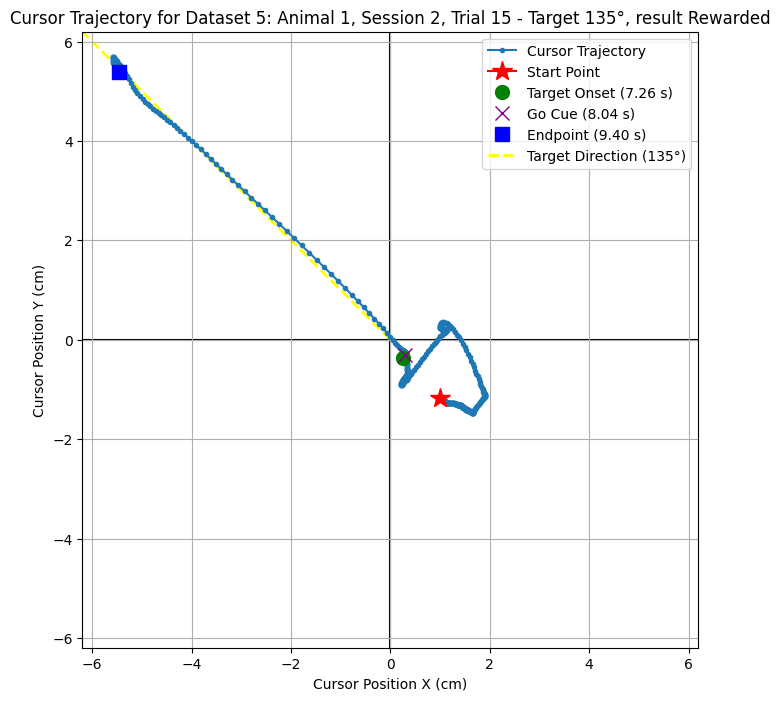

In [71]:
plot_cursor_trajectory(df_gpb_session_trial)

In [72]:
import numpy as np

# Initialize a list to store results for each trial
trial_go_cue_ranges = []

# Group by animal, session, and trial_id
grouped_df = anix_dat1_df.groupby(['animal', 'session', 'trial_id'])

for (animal, session, trial_id), trial_df in grouped_df:
    # Find the time of the first EventTarget_Onset
    target_onsets = trial_df[trial_df['EventTarget_Onset'] == True]['time_s']

    # Find the time of the first EventGo_cue
    go_cue_onsets = trial_df[trial_df['EventGo_cue'] == True]['time_s']

    if not target_onsets.empty and not go_cue_onsets.empty:
        first_target_onset_time = target_onsets.iloc[0]
        first_go_cue_time = go_cue_onsets.iloc[0]

        # Calculate relative go cue onset time
        relative_go_cue_onset = first_go_cue_time - first_target_onset_time

        # Collect data for the trial
        trial_go_cue_ranges.append({
            'animal': animal,
            'session': session,
            'trial_id': trial_id,
            'relative_go_cue_onset': relative_go_cue_onset
        })

# Convert the list of dictionaries to a DataFrame
df_relative_go_cues = pd.DataFrame(trial_go_cue_ranges)

# Filter for trials where 'relative_go_cue_onset' is close to 15.66
target_value = 15.66
tolerance = 0.5 # Define a tolerance for 'close'

filtered_trials = df_relative_go_cues[
    (df_relative_go_cues['relative_go_cue_onset'] >= target_value - tolerance) &
    (df_relative_go_cues['relative_go_cue_onset'] <= target_value + tolerance)
]

if not filtered_trials.empty:
    print(f"Trials with 'relative_go_cue_onset' close to {target_value} seconds (within +/- {tolerance}s):")
    display(filtered_trials)
else:
    print(f"No trials found with 'relative_go_cue_onset' close to {target_value} seconds (within +/- {tolerance}s).")

Trials with 'relative_go_cue_onset' close to 15.66 seconds (within +/- 0.5s):


,animal,session,trial_id,relative_go_cue_onset
1133,1,7,25,15.66


In [73]:
session_selected = 7
trial_selected = 25

if type(merged_dat1_df['session'][0]) == str:
  session_selected = str(session_selected)

if type(merged_dat1_df['trial_id'][0]) == str:
  trial_selected = str(trial_selected)

df_gpb_session_trial = anix_dat1_df[(anix_dat1_df['session'] == session_selected) & (anix_dat1_df['trial_id'] == trial_selected)]
df_gpb_session_trial

,time_s,trial_id,animal,datasetID,session,brain_region,EventGo_cue,EventTarget_Onset,target_ID,target_dir,result,cursor_pos_x,cursor_pos_y,cursor_vel_x,cursor_vel_y,cursor_acc_x,cursor_acc_y
576690,5766.90,25,1,5,7,NaN,False,False,4.0,-1.570796,R,0.369853,7.260236,-0.799005,-4.254265,-15.267248,-49.250841
576691,5766.91,25,1,5,7,NaN,False,True,4.0,-1.570796,R,0.361105,7.215146,-0.975534,-4.802437,-18.168917,-57.120587
576692,5766.92,25,1,5,7,NaN,False,False,4.0,-1.570796,R,0.350342,7.164188,-1.162384,-5.396677,-16.947115,-58.915548
576693,5766.93,25,1,5,7,NaN,False,False,4.0,-1.570796,R,0.337858,7.107213,-1.314476,-5.980748,-15.017157,-56.240295
576694,5766.94,25,1,5,7,NaN,False,False,4.0,-1.570796,R,0.324053,7.044573,-1.462727,-6.521483,-16.520991,-51.536061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578389,5783.89,25,1,5,7,NaN,False,False,4.0,-1.570796,R,5.631068,5.735977,0.196003,-0.152071,2.935206,-0.915516
578390,5783.90,25,1,5,7,NaN,False,False,4.0,-1.570796,R,5.633607,5.734295,0.282645,-0.197432,-1.336818,1.189046
578391,5783.91,25,1,5,7,NaN,False,False,4.0,-1.570796,R,5.636721,5.732028,0.169267,-0.12829,-20.985135,15.940347
578392,5783.92,25,1,5,7,NaN,False,False,4.0,-1.570796,R,5.636992,5.731729,-0.137058,0.121375,-23.239078,18.788423


Target direction for session  7 , trial  25 :  -90.0  degrees


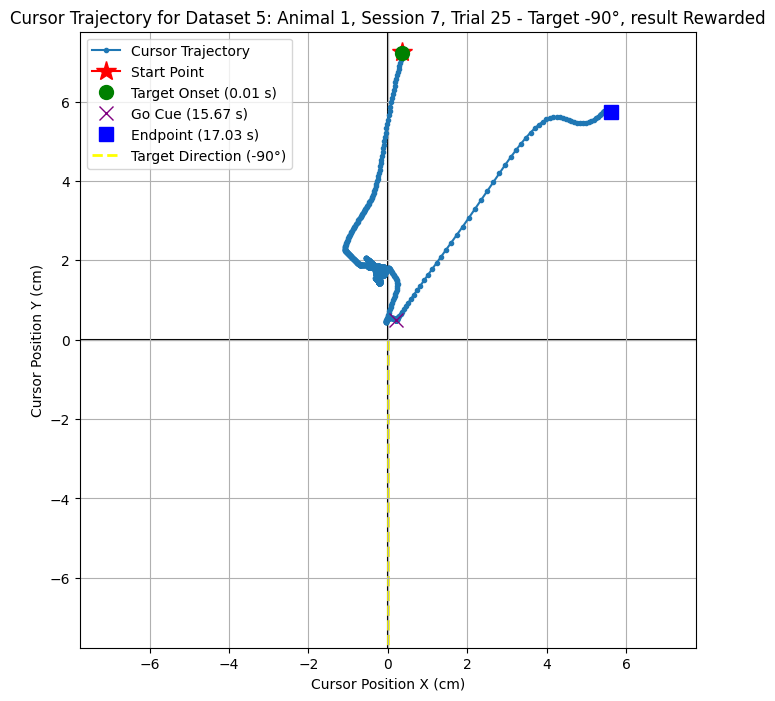

In [74]:
plot_cursor_trajectory(df_gpb_session_trial)

It seems this trial should be classified as result = F (Failed), but is classified as R (Rewarded)

In [75]:
unique_target_ids = anix_dat1_df['target_ID'].dropna().unique()

for target_id in unique_target_ids:
    unique_target_dirs_rad = anix_dat1_df[anix_dat1_df['target_ID'] == target_id]['target_dir'].unique()
    # Convert to degrees, handling potential NaN values
    unique_target_dirs_deg = [np.degrees(d) if not pd.isna(d) else np.nan for d in unique_target_dirs_rad]
    print(f"Unique target_dir values for target_ID = {target_id} (degrees):")
    display(np.array(unique_target_dirs_deg))

Unique target_dir values for target_ID = 6.0 (degrees):


array([180.])

Unique target_dir values for target_ID = 2.0 (degrees):


array([0.])

Unique target_dir values for target_ID = 0.0 (degrees):


...

array([-135.])

Unique target_dir values for target_ID = 12.0 (degrees):


array([nan])

Unique target_dir values for target_ID = 8.0 (degrees):


array([nan])